Used dataset: **Ames Housing Dataset**

In [179]:
import kagglehub
import pandas as pd
import numpy as np
import os

if(not os.path.isdir('data')):
    path = kagglehub.dataset_download("shashanknecrothapa/ames-housing-dataset", output_dir='./data')

    print("Path to dataset:", path)

df = pd.read_csv('./data/AmesHousing.csv')

print(df.shape)  # (2930, 82)
df.head()

(2930, 82)


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


# Przygotowanie danych

* Obsługa braków w danych
* Zamiana Stringów
* Usuwanie outliersów (Z-score, IQR method, visually)
* Standaryzacja (StandardScaler)
* Numeric skew transforms (log1p)

In [180]:
df.drop(columns=['Order', 'PID', 'Garage Yr Blt', 'Mo Sold', 'Condition 2', 'Roof Matl', 'Heating'], inplace=True)

In [181]:
# Fill categorical "absent" columns with 'None'
none_cols = [ 'Alley', 'Mas Vnr Type', 'Bsmt Qual', 'Bsmt Cond',
                'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2',
                'Fireplace Qu', 'Garage Type', 'Garage Finish',
                'Garage Qual', 'Garage Cond', 'Pool QC', 'Fence', 'Misc Feature' 
]
df[none_cols] = df[none_cols].fillna('None')

# Fill numeric absent columns with 0
zero_cols = [ 'Lot Frontage', 'Mas Vnr Area', 'BsmtFin SF 1', 'BsmtFin SF 2',
                'Bsmt Unf SF', 'Total Bsmt SF', 'Bsmt Full Bath', 'Bsmt Half Bath',
                'Garage Cars', 'Garage Area' 
]
df[zero_cols] = df[zero_cols].fillna(0)

df['Electrical'] = df['Electrical'].fillna('SBrkr')

In [182]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [183]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, TargetEncoder

ordinal_cols = {
    'Lot Shape':        ['IR3', 'IR2', 'IR1', 'Reg'],
    'Utilities':        ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'Land Slope':       ['Gtl', 'Mod', 'Sev'],
    'Exter Qual':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Exter Cond':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Qual':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Cond':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Exposure':    ['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFin Type 1':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFin Type 2':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'Central Air':      ['N', 'Y'],
    'Electrical':       ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
    'Kitchen Qual':     ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Functional':       ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'Fireplace Qu':     ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Finish':    ['None', 'Unf', 'RFn', 'Fin'],
    'Garage Qual':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Cond':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Paved Drive':      ['N', 'P', 'Y'],
    'Pool QC':          ['None', 'Fa', 'TA', 'Gd', 'Ex'],
    'Fence':            ['None', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    'Heating QC':       [ 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
}

for col, order in ordinal_cols.items():
    enc = OrdinalEncoder(
    categories=[order],
    handle_unknown='use_encoded_value',
    unknown_value=-1         
    )
    X_train[col] = enc.fit_transform(X_train[[col]]).ravel()
    X_test[col] = enc.transform(X_test[[col]]).ravel()

one_hot_cols = [ 'MS Zoning', 'Street', 'Alley', 'Land Contour',
                    'Lot Config', 'Bldg Type', 'House Style', 'Roof Style',
                    'Mas Vnr Type', 'Foundation',
                ]

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', dtype=float)

ohe_train = pd.DataFrame(ohe.fit_transform(X_train[one_hot_cols]), columns=ohe.get_feature_names_out(one_hot_cols), index=X_train.index)
ohe_test = pd.DataFrame(ohe.transform(X_test[one_hot_cols]), columns=ohe.get_feature_names_out(one_hot_cols), index=X_test.index)

X_train = pd.concat([X_train.drop(columns=one_hot_cols), ohe_train], axis=1)
X_test = pd.concat([X_test.drop(columns=one_hot_cols), ohe_test], axis=1)


target_cols = [ 'MS SubClass', 'Neighborhood', 'Condition 1', 'Garage Type',
                    'Misc Feature', 'Sale Type', 'Sale Condition', 'Exterior 1st',
                    'Exterior 2nd'
                ]

te = TargetEncoder(target_type="continuous", random_state=42)
X_train[target_cols] = te.fit_transform(X_train[target_cols], y_train)
X_test[target_cols]  = te.transform(X_test[target_cols])

In [184]:
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso.fit(X_train)

train_iso_mask  = iso.predict(X_train) == -1
train_iso_scores = iso.score_samples(X_train)

test_iso_mask   = iso.predict(X_test) == -1
test_iso_scores  = iso.score_samples(X_test)

print(f"Train outliers: {train_iso_mask.sum()} ({train_iso_mask.mean()*100:.1f}%)")
print(f"Test  outliers: {test_iso_mask.sum()}  ({test_iso_mask.mean()*100:.1f}%)")


Train outliers: 118 (5.0%)
Test  outliers: 33  (5.6%)


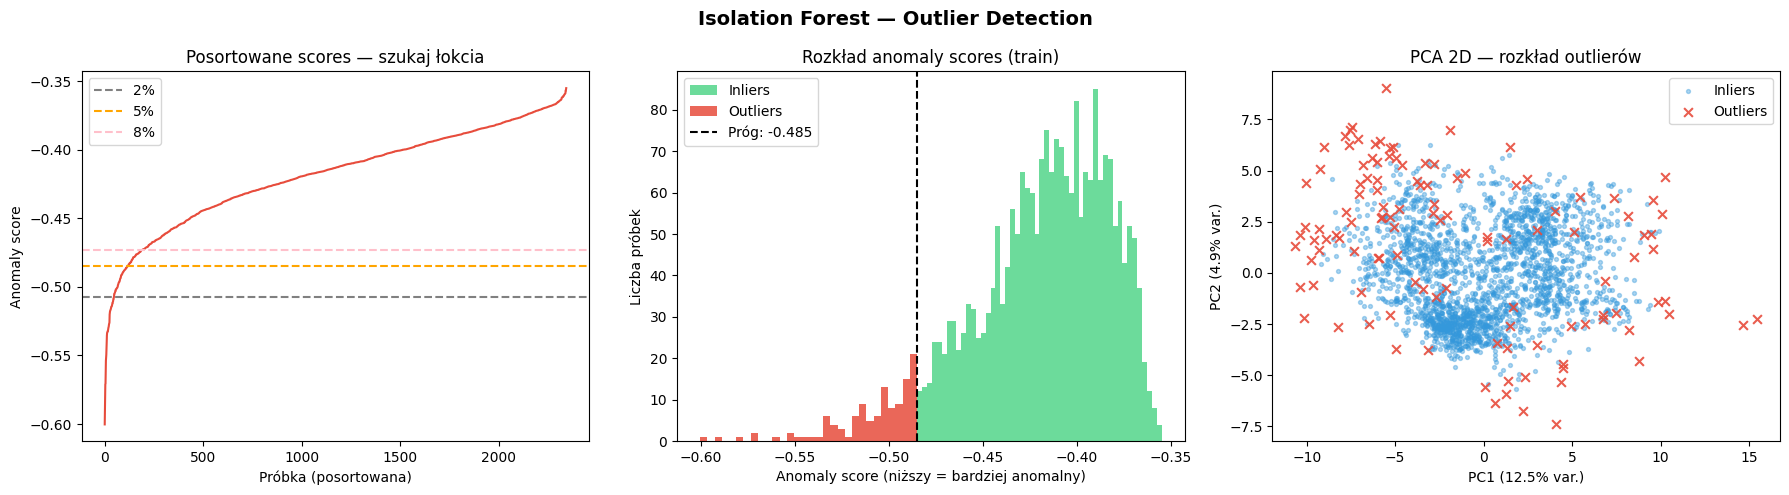

In [185]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Isolation Forest — Outlier Detection", fontsize=14, fontweight='bold')

# Elbow method for contamination
scores = iso.score_samples(X_train)
ax = axes[0]
ax.plot(np.sort(scores), color='#e74c3c', linewidth=1.5)
ax.set_title('Posortowane scores — szukaj łokcia')
ax.set_xlabel('Próbka (posortowana)')
ax.set_ylabel('Anomaly score')
ax.axhline(np.percentile(scores, 2), color='gray',
                linestyle='--', label='2%')
ax.axhline(np.percentile(scores, 5), color='orange',
                linestyle='--', label='5%')
ax.axhline(np.percentile(scores, 8), color='pink',
                linestyle='--', label='8%')
ax.legend()

# Histogram anomaly scores
ax = axes[1]
ax.hist(train_iso_scores[~train_iso_mask], bins=50,
        color='#2ecc71', alpha=0.7, label='Inliers')
ax.hist(train_iso_scores[train_iso_mask], bins=30,
        color='#e74c3c', alpha=0.85, label='Outliers')
ax.axvline(iso.offset_, color='black', linestyle='--',
           linewidth=1.5, label=f'Próg: {iso.offset_:.3f}')
ax.set_title('Rozkład anomaly scores (train)')
ax.set_xlabel('Anomaly score (niższy = bardziej anomalny)')
ax.set_ylabel('Liczba próbek')
ax.legend()

# PCA 2D scatter
pca = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(StandardScaler().fit_transform(X_train))

ax = axes[2]
ax.scatter(X_2d[~train_iso_mask, 0], X_2d[~train_iso_mask, 1],
           s=8, alpha=0.4, color='#3498db', label='Inliers')
ax.scatter(X_2d[train_iso_mask, 0], X_2d[train_iso_mask, 1],
           s=40, alpha=0.9, color='#e74c3c', marker='x',
           linewidths=1.5, label='Outliers')
ax.set_title('PCA 2D — rozkład outlierów')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)')
ax.legend()

plt.tight_layout()
# plt.savefig('isolation_forest_outliers.png', dpi=150, bbox_inches='tight')
plt.show()

X_train_clean = X_train[~train_iso_mask]
y_train_clean = y_train[~train_iso_mask]
X_test_clean = X_test[~test_iso_mask]
y_test_clean = y_test[~test_iso_mask]

In [186]:
scaler = StandardScaler()
X_train_clean = scaler.fit_transform(X_train_clean)
X_test_clean = scaler.fit(X_test_clean)

# Wizualizacja danych

* Wykresy pokazujące zależność między cechami a ceną. 
* TABELE
* Wykresy danych w 2d i 3d

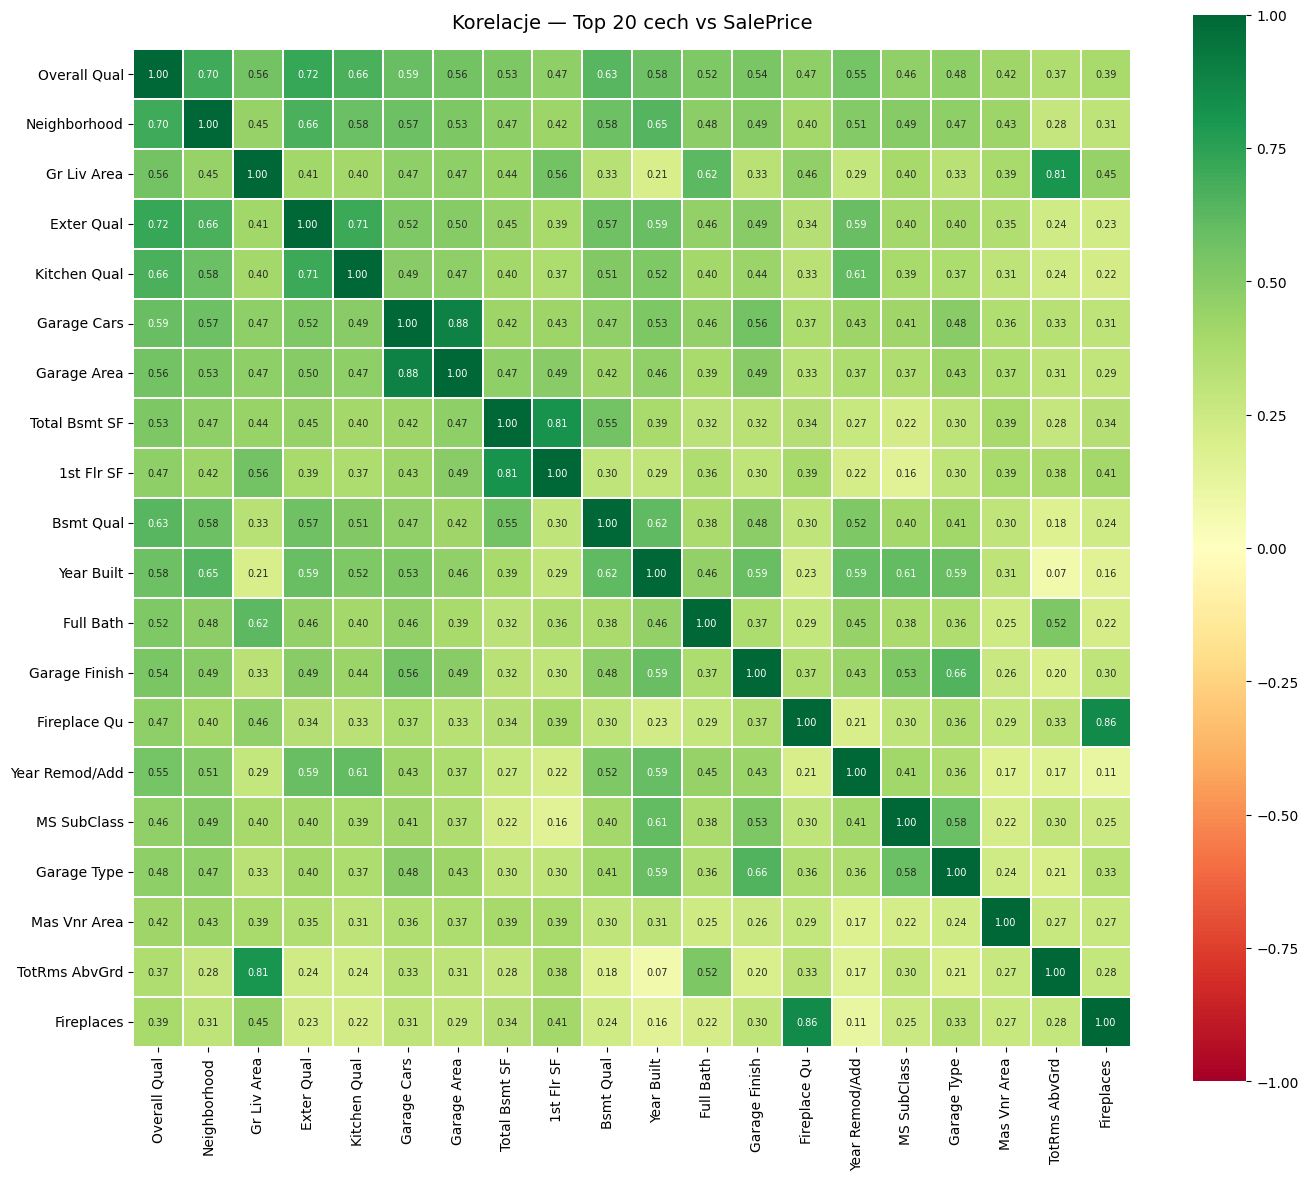

In [187]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

feature_names = df.columns
df = pd.DataFrame(X_train, columns=feature_names)
df['SalePrice'] = y_train

# ── TOP 20 cech najsilniej skorelowanych z ceną ───────────────
corr = df.corr()
top20 = corr['SalePrice'].abs().sort_values(ascending=False)[1:21].index
corr_top20 = df[top20].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    corr_top20,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.3,
    ax=ax
)
ax.set_title('Korelacje — Top 20 cech vs SalePrice', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('heatmap_top20.png', dpi=150, bbox_inches='tight')
plt.show()

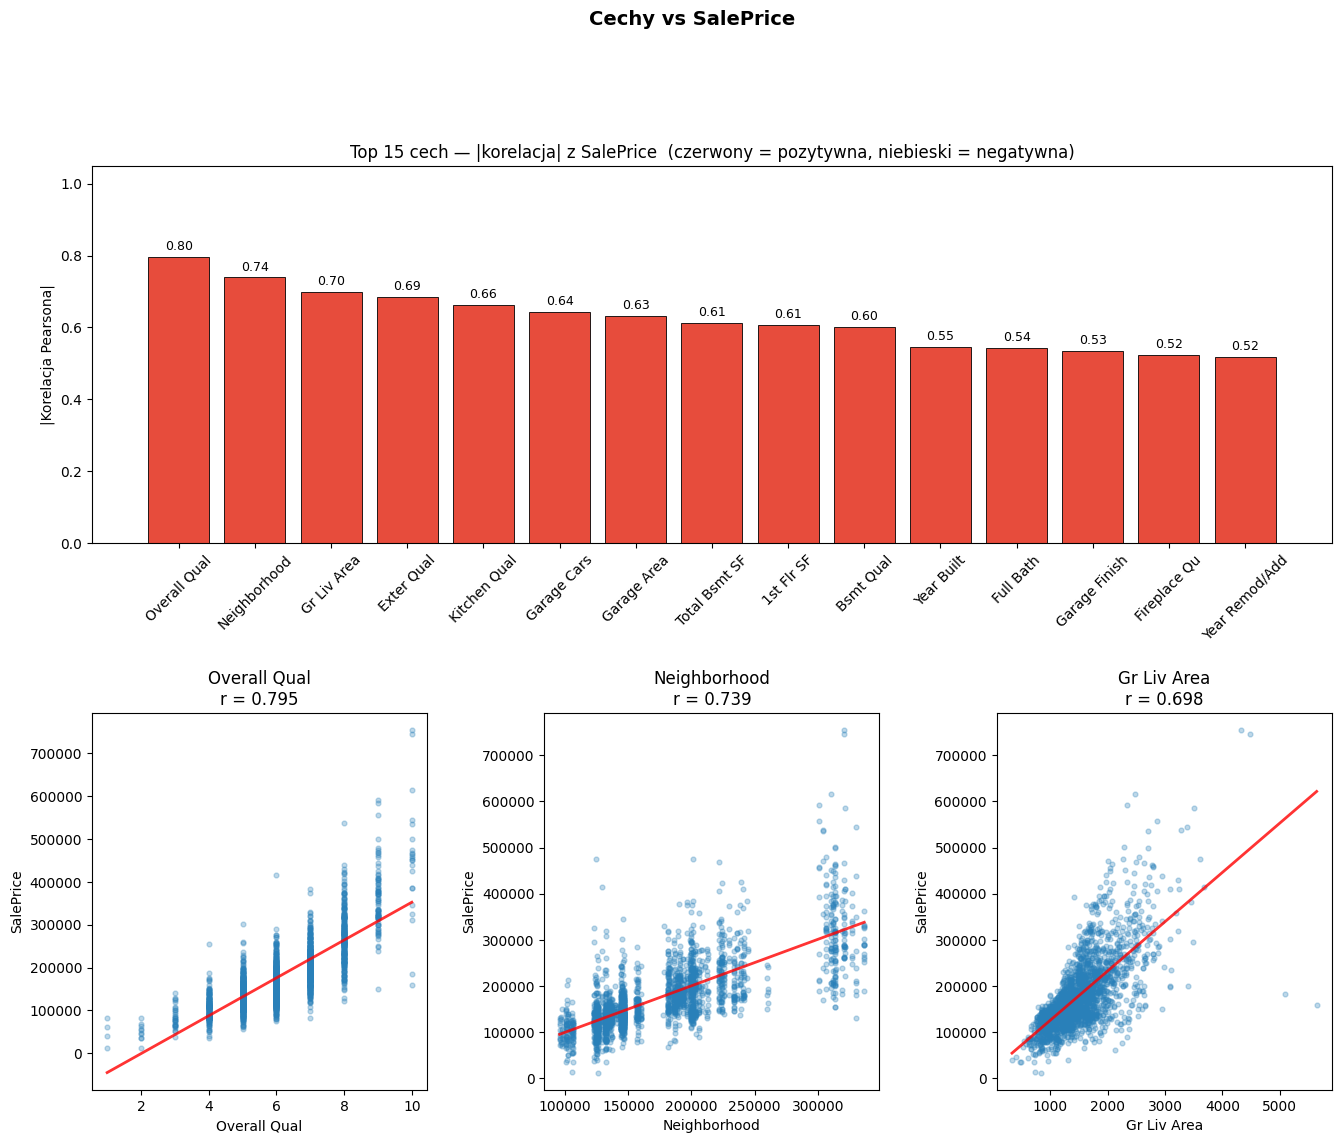

In [188]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# ── 2a. Bar chart — korelacja każdej cechy z SalePrice ───────
ax1 = fig.add_subplot(gs[0, :])   # cały górny rząd
top15 = corr['SalePrice'].drop('SalePrice').abs() \
            .sort_values(ascending=False).head(15)
colors = ['#e74c3c' if corr['SalePrice'][f] > 0 
          else '#3498db' for f in top15.index]
bars = ax1.bar(top15.index, top15.values, color=colors, edgecolor='black', lw=0.6)
ax1.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax1.set_title('Top 15 cech — |korelacja| z SalePrice  '
              '(czerwony = pozytywna, niebieski = negatywna)')
ax1.set_ylabel('|Korelacja Pearsona|')
ax1.set_ylim(0, 1.05)
ax1.tick_params(axis='x', rotation=45)

# ── 2b-d. Scatter: top 3 cechy vs SalePrice ──────────────────
top3 = corr['SalePrice'].drop('SalePrice').abs() \
           .sort_values(ascending=False).head(3).index

for i, feat in enumerate(top3):
    ax = fig.add_subplot(gs[1, i])
    ax.scatter(df[feat], df['SalePrice'],
               alpha=0.3, s=12, color='#2980b9')
    
    # linia trendu
    z = np.polyfit(df[feat].dropna(), 
                   df.loc[df[feat].notna(), 'SalePrice'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[feat].min(), df[feat].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2, alpha=0.8)
    
    r = corr['SalePrice'][feat]
    ax.set_title(f'{feat}\nr = {r:.3f}')
    ax.set_xlabel(feat)
    ax.set_ylabel('SalePrice')

plt.suptitle('Cechy vs SalePrice', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('correlations.png', dpi=150, bbox_inches='tight')
plt.show()

In [189]:
# ── Pełna tabela statystyk per cecha ─────────────────────────
stats_df = pd.DataFrame({
    'mean':     df[feature_names].mean(),
    'median':   df[feature_names].median(),
    'std':      df[feature_names].std(),
    'skew':     df[feature_names].skew(),
    'kurtosis': df[feature_names].kurtosis(),
    'corr_price': corr['SalePrice'].drop('SalePrice'),
}).round(3)

# Flagi — co wymaga uwagi
stats_df['⚠️ skew']    = stats_df['skew'].abs() > 1      # silna asymetria
stats_df['⭐ ważna']   = stats_df['corr_price'].abs() > 0.4  # silna korelacja

# Posortuj po korelacji z ceną
stats_df = stats_df.sort_values('corr_price', ascending=False, key=abs)

print("=== TOP 15 najważniejszych cech ===")
print(stats_df.head(15).to_string())

# Export do CSV jeśli chcesz otworzyć w Excelu
stats_df.to_csv('feature_stats.csv')

=== TOP 15 najważniejszych cech ===
                      mean      median        std   skew  kurtosis  corr_price  ⚠️ skew  ⭐ ważna
Overall Qual         6.064       6.000      1.389  0.204     0.160       0.795    False     True
Neighborhood    178099.014  157717.883  56651.982  1.102     0.706       0.739     True     True
Gr Liv Area       1492.860    1436.500    504.620  1.303     4.419       0.698     True     True
Exter Qual           2.388       2.000      0.576  0.808     0.111       0.685    False     True
Kitchen Qual         2.491       2.000      0.655  0.447    -0.204       0.661    False     True
Garage Cars          1.746       2.000      0.747 -0.214     0.209       0.644    False     True
Garage Area        468.879     476.000    212.608  0.290     1.122       0.633    False     True
Total Bsmt SF     1046.576     988.000    437.009  1.336    11.424       0.613     True     True
1st Flr SF        1154.814    1082.000    385.114  1.542     8.222       0.607     True    